In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install segmentation-models-pytorch
!pip install pycocotools albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [4]:
import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import segmentation_models_pytorch as smp

from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
!ls /content/drive/MyDrive/

 17109614855781527023913702020336-compressed.jpg.jpg
'2341018060 (2).pdf'
 254.xlsx
'5th sem admit card.pdf'
'admit card (1).pdf'
'admit card.pdf'
'CNC-project report format-1.gdoc'
'CNC-project report format-1.pdf'
'CN Project 5 report.docx'
'Colab Notebooks'
'Computer Institute Management System Project.gdoc'
'Computer Institute Management System Project.pdf'
'Copy of PYQ_MidSem_COA (1).pdf'
'Copy of PYQ_MidSem_COA.pdf'
"Copy of White and Black Illustrative National Engineer's Day Instagram Post_20250915_140005_0000.png"
 d7d91c24-fc8f-48ab-b199-471c3bf59095_copy.pdf
'file_00000000bf9061f981a7907ee085d142 (1).png'
'file_00000000bf9061f981a7907ee085d142 (2).png'
 file_00000000bf9061f981a7907ee085d142.png
'From the Resume, day 1'
'Gmail - SOA B.TECH. Orientation Class (1).pdf'
'Gmail - SOA BTECH PROVISONAL ALLOTMENT (1).pdf'
 IMG-20231113-WA0025.jpeg
 IMG-20231215-WA0016.jpg
'IMG20240925225409 (1).jpg'
 IMG20240925225409.jpg
'IMG_20250315_222123 (1).jpg'
'IMG_20250315_222123 (2).jpg'
 

In [7]:
!ls /content/drive/MyDrive/VisionExtract

final_model.pth  model.pth


In [8]:
!wget http://images.cocodataset.org/zips/train2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip -q train2017.zip
!unzip -q annotations_trainval2017.zip

--2026-03-02 13:01:25--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.199.74, 52.217.171.137, 16.15.207.176, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.199.74|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  42.2MB/s    in 6m 23s  

2026-03-02 13:07:49 (48.1 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]

--2026-03-02 13:07:49--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.230.217, 3.5.28.164, 52.217.197.129, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.230.217|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotat

In [9]:
ANNOTATION_PATH = "/content/annotations/instances_train2017.json"
coco = COCO(ANNOTATION_PATH)

print("Total images:", len(coco.getImgIds()))

loading annotations into memory...
Done (t=13.46s)
creating index...
index created!
Total images: 118287


In [10]:
ANNOTATION_PATH = "/content/drive/MyDrive/VisionExtract/annotations/instances_train2017.json"

coco = COCO(ANNOTATION_PATH)
print("Total images:", len(coco.getImgIds()))

loading annotations into memory...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/VisionExtract/annotations/instances_train2017.json'

In [11]:
# Define target categories
target_classes = [
    'person',
    'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
    'banana','apple','sandwich','orange','broccoli','carrot',
    'hot dog','pizza','donut','cake'
]

# Get category IDs
cat_ids = coco.getCatIds(catNms=target_classes)

print("Selected category IDs:", cat_ids)

# Get image IDs for selected categories
img_ids = coco.getImgIds(catIds=cat_ids)

print("Images for selected categories:", len(img_ids))

Selected category IDs: [1, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]
Images for selected categories: 0


In [12]:
img_ids = img_ids[:3000]

split_index = int(0.8 * len(img_ids))

train_ids = img_ids[:split_index]
val_ids = img_ids[split_index:]

print("Train:", len(train_ids))
print("Val:", len(val_ids))

Train: 0
Val: 0


In [13]:
def get_mask(img_id):
    img_info = coco.loadImgs(img_id)[0]
    height, width = img_info['height'], img_info['width']

    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=cat_ids)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((height, width))

    for ann in anns:
        mask += coco.annToMask(ann)

    mask = (mask > 0).astype(np.uint8)
    return mask

In [14]:
class CocoSegDataset(Dataset):
    def __init__(self, img_ids):
        self.img_ids = img_ids

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = coco.loadImgs(img_id)[0]

        img_path = os.path.join(
            "/content/drive/MyDrive/VisionExtract/train2017",
            img_info['file_name']
        )

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = get_mask(img_id)

        image = cv2.resize(image, (256,256))
        mask = cv2.resize(mask, (256,256))

        image = torch.tensor(image).permute(2,0,1).float()/255.0
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [15]:
print("Total COCO images:", len(coco.getImgIds()))

print("Selected category IDs:", cat_ids)

img_ids = coco.getImgIds(catIds=cat_ids)
print("Images for selected categories:", len(img_ids))

img_ids = img_ids[:3000]
print("Images after limiting:", len(img_ids))

split_index = int(0.8 * len(img_ids))
print("Split index:", split_index)

train_ids = img_ids[:split_index]
val_ids = img_ids[split_index:]

print("Train IDs count:", len(train_ids))
print("Val IDs count:", len(val_ids))

Total COCO images: 118287
Selected category IDs: [1, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]
Images for selected categories: 0
Images after limiting: 0
Split index: 0
Train IDs count: 0
Val IDs count: 0


In [16]:
print(coco.dataset.keys())

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])


In [17]:
print(coco.loadCats(coco.getCatIds()))

[{'supercategory': 'person', 'id': 1, 'name': 'person'}, {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'}, {'supercategory': 'vehicle', 'id': 3, 'name': 'car'}, {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'}, {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'}, {'supercategory': 'vehicle', 'id': 6, 'name': 'bus'}, {'supercategory': 'vehicle', 'id': 7, 'name': 'train'}, {'supercategory': 'vehicle', 'id': 8, 'name': 'truck'}, {'supercategory': 'vehicle', 'id': 9, 'name': 'boat'}, {'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'}, {'supercategory': 'outdoor', 'id': 11, 'name': 'fire hydrant'}, {'supercategory': 'outdoor', 'id': 13, 'name': 'stop sign'}, {'supercategory': 'outdoor', 'id': 14, 'name': 'parking meter'}, {'supercategory': 'outdoor', 'id': 15, 'name': 'bench'}, {'supercategory': 'animal', 'id': 16, 'name': 'bird'}, {'supercategory': 'animal', 'id': 17, 'name': 'cat'}, {'supercategory': 'animal', 'id': 18, 'name': 'dog'}, {'supercategory

In [18]:
coco = COCO("/content/annotations/instances_train2017.json")

loading annotations into memory...
Done (t=14.25s)
creating index...
index created!


In [19]:
coco = COCO("/content/annotations/instances_train2017.json")

print("Total images:", len(coco.getImgIds()))

target_classes = [
    'person',
    'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
    'banana','apple','sandwich','orange','broccoli','carrot',
    'hot dog','pizza','donut','cake'
]

cat_ids = coco.getCatIds(catNms=target_classes)
print("Category IDs:", cat_ids)

img_ids = coco.getImgIds(catIds=cat_ids)
print("Images found:", len(img_ids))

loading annotations into memory...
Done (t=13.75s)
creating index...
index created!
Total images: 118287
Category IDs: [1, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]
Images found: 0


In [20]:
img_ids = coco.getImgIds()
print("Total images:", len(img_ids))

Total images: 118287


In [21]:
img_ids = coco.getImgIds()
print("Total images available:", len(img_ids))

Total images available: 118287


In [22]:
img_ids = img_ids[:3000]

In [23]:
img_ids = coco.getImgIds()
img_ids = img_ids[:3000]

split_index = int(0.8 * len(img_ids))

train_ids = img_ids[:split_index]
val_ids = img_ids[split_index:]

print("Train:", len(train_ids))
print("Val:", len(val_ids))

Train: 2400
Val: 600


In [24]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model ready ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model ready ✅


In [25]:
# Create Dataset objects
train_dataset = CocoSegDataset(train_ids)
val_dataset = CocoSegDataset(val_ids)

# Create DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

print("DataLoader ready ✅")
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

DataLoader ready ✅
Train batches: 600
Val batches: 150


In [26]:
class CocoSegDataset(Dataset):
    def __init__(self, img_ids):
        self.img_ids = img_ids

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = coco.loadImgs(img_id)[0]

        # ✅ Correct image path
        img_path = os.path.join(
            "/content/train2017",
            img_info['file_name']
        )

        image = cv2.imread(img_path)

        # Safety check
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = get_mask(img_id)

        image = cv2.resize(image, (256,256))
        mask = cv2.resize(mask, (256,256))

        image = torch.tensor(image).permute(2,0,1).float() / 255.0
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [27]:
train_dataset = CocoSegDataset(train_ids)
val_dataset = CocoSegDataset(val_ids)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 600
Val batches: 150


In [28]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model ready ✅")

Model ready ✅


In [29]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.3925412817547719
Epoch 2, Loss: 0.2227968577047189
Epoch 3, Loss: 0.1818293049931526
Epoch 4, Loss: 0.15456862873087326
Epoch 5, Loss: 0.13839945315693816


In [32]:
def iou_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection

    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

In [33]:
model.eval()
total_iou = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        total_iou += iou_score(outputs, masks)

print("Validation IoU:", total_iou / len(val_loader))

Validation IoU: 0.5788845406005081


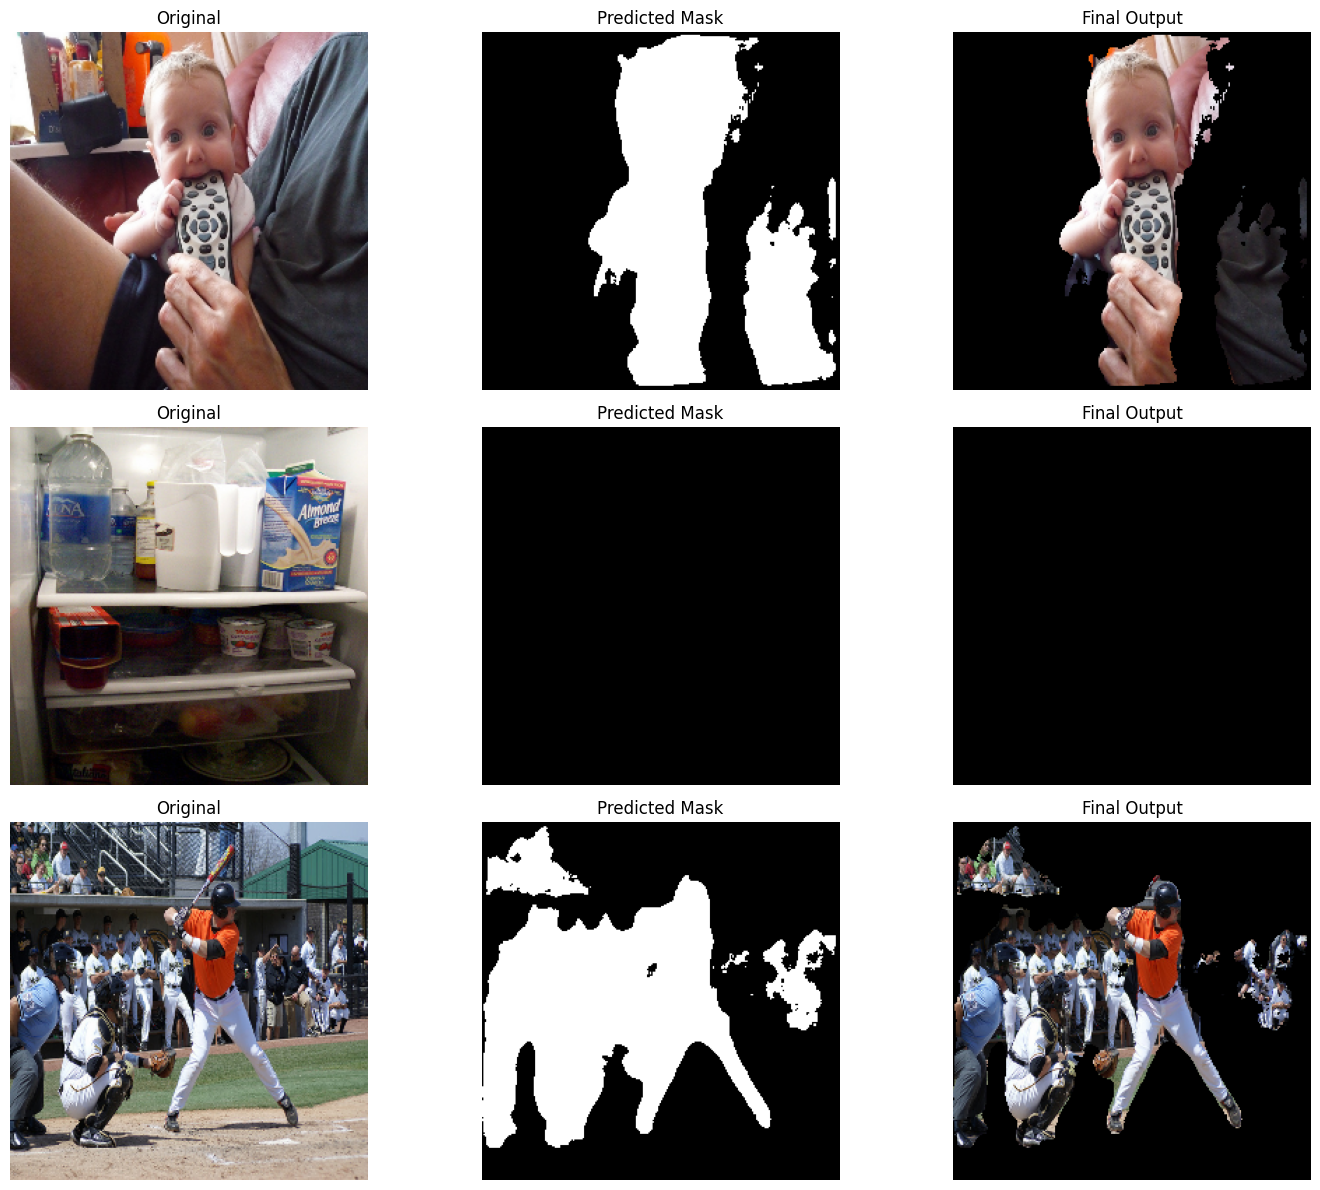

In [34]:
import random
import matplotlib.pyplot as plt

model.eval()

indices = random.sample(range(len(val_dataset)), 3)

plt.figure(figsize=(15,12))

for row, idx in enumerate(indices):
    image, _ = val_dataset[idx]
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image)

    pred = torch.sigmoid(pred)
    pred_binary = (pred > 0.5).float()
    output = image * pred_binary

    original = image.squeeze(0).cpu().permute(1,2,0).numpy()
    mask = pred_binary.squeeze(0).cpu().squeeze(0).numpy()
    final = output.squeeze(0).cpu().permute(1,2,0).numpy()

    plt.subplot(3,3,row*3+1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,3,row*3+2)
    plt.imshow(mask, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(3,3,row*3+3)
    plt.imshow(final)
    plt.title("Final Output")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# -------------------------------
# Fine-Tuning Block (Week 4)
# -------------------------------

best_iou = 0

for epoch in range(5):   # 5 more epochs
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ---- Validation ----
    model.eval()
    total_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            # Lower threshold for better detection
            pred = torch.sigmoid(outputs)
            pred_binary = (pred > 0.3).float()

            intersection = (pred_binary * masks).sum(dim=(1,2,3))
            union = pred_binary.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) - intersection
            iou = (intersection + 1e-6) / (union + 1e-6)

            total_iou += iou.mean().item()

    avg_iou = total_iou / len(val_loader)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val IoU: {avg_iou:.4f}")

    # ---- Save Best Model ----
    if avg_iou > best_iou:
        best_iou = avg_iou
        torch.save(model.state_dict(),
                   "/content/drive/MyDrive/VisionExtract/best_model.pth")
        print("Best model saved ✅")

print("Training Complete 🔥")
print("Best Validation IoU:", best_iou)

Epoch 1 | Loss: 0.1271 | Val IoU: 0.5227
Best model saved ✅
Epoch 2 | Loss: 0.1126 | Val IoU: 0.5656
Best model saved ✅
Epoch 3 | Loss: 0.1046 | Val IoU: 0.5670
Best model saved ✅
Epoch 4 | Loss: 0.1048 | Val IoU: 0.4980
Epoch 5 | Loss: 0.0954 | Val IoU: 0.5977
Best model saved ✅
Training Complete 🔥
Best Validation IoU: 0.5977172418683767


In [36]:
torch.save(model.state_dict(),
"/content/drive/MyDrive/VisionExtract/final_model.pth")

In [37]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/VisionExtract/final_model.pth"
)

print("Model saved permanently ✅")

Model saved permanently ✅


In [38]:
from google.colab import files
files.download("/content/drive/MyDrive/VisionExtract/final_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>